# **Identifying Key Entities in Recipe Data**


**Business Objective**:
The goal of this assignment is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model will classify words into predefined categories such as ingredients, quantities and units, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**. Below is a breakdown of the data fields:

```json
[
    {
        "input": "6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil",
        "pos": "quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient"
    },
    {
      "input": "2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida",
      "pos": "quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient"
    }
]


| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags or NER labels, identifying quantities, ingredients, and units. |


## **1** Import libraries

#### **1.1** Installation of sklearn-crfsuite

sklearn-crfsuite is a Python wrapper for CRFsuite, a fast and efficient implementation of Conditional Random Fields (CRFs). It is designed to integrate seamlessly with scikit-learn for structured prediction tasks such as Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and chunking.

In [44]:
import json
import re
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn_crfsuite

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn_crfsuite.metrics import flat_classification_report

In [3]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### **1.2** Import necessary libraries

In [2]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [45]:
# Import necessary libraries
import json  # For handling JSON data
import pandas as pd  # For data manipulation and analysis
import re  # For regular expressions (useful for text preprocessing)
import matplotlib.pyplot as plt  # For visualisation
import seaborn as sns  # For advanced data visualisation
import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
import numpy as np  # For numerical computations
# Saving and loading machine learning models
import joblib
import random
import spacy
from IPython.display import display, Markdown # For displaying well-formatted output

from fractions import Fraction  # For handling fractional values in numerical data
# Importing tools for feature engineering and model training
from collections import Counter  # For counting occurrences of elements in a list
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn_crfsuite import metrics  # For evaluating CRF models
from sklearn_crfsuite.metrics import flat_classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.metrics import confusion_matrix

In [ ]:
# Ensure pandas displays full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

## **2** Data Ingestion and Preparation <font color = red>[25 marks]</font> <br>

#### **2.1** *Read Recipe Data from Dataframe and prepare the data for analysis* <font color = red>[12 marks]</font> <br>
Read the data from JSON file, print first five rows and describe the dataframe

##### **2.1.1** **Define a *load_json_dataframe* function** <font color = red>[7 marks]</font> <br>

Define a function that takes path of the ingredient_and_quantity.json file and reads it, convert it into dataframe - df and return it.

In [10]:
# define a function to load json file to a dataframe
import json
import pandas as pd

def load_json_dataframe(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    
    return pd.DataFrame(data)

##### **2.1.2** **Execute the *load_json_dataframe* function** <font color = red>[2 marks]</font> <br>

In [12]:
# read the json file by giving the file path and create a dataframe
df = load_json_dataframe(
    r"D:\Downloads\Starter+Notebook+++Data (2)\ingredient_and_quantity.json"
)




##### **2.1.3** **Describe the dataframe** <font color = red>[3 marks]</font> <br>

Print first five rows of dataframe along with dimensions. Display the information of dataframe

In [13]:
# display first five rows of the dataframe - df
display(df.head())

,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 ...,quantity ingredient ingredient ingredient ingr...
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC...,quantity unit ingredient ingredient quantity i...
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onio...,quantity unit ingredient ingredient ingredient...
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 G...,quantity unit ingredient quantity ingredient i...
4,1 tablespoon chana dal white urad 2 red chilli...,quantity unit ingredient ingredient ingredient...


In [14]:
# print the dimensions of dataframe - df
print("Dimensions:", df.shape)

Dimensions: (285, 2)


In [15]:
# print the information of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


#### **2.2** *Recipe Data Manipulation* <font color = red>[13 marks]</font> <br>
Create derived metrics in dataframe and provide insights of the dataframe

##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe** <font color = red>[3 marks]</font> <br>
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [16]:
# split the input and pos into input_tokens and pos_tokens in the dataframe
# Tokenize input
df["input_tokens"] = df["input"].str.split()

# Tokenize POS
df["pos_tokens"] = df["pos"].str.split()

display(df[["input", "pos", "input_tokens", "pos_tokens"]].head())


,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 ...,quantity ingredient ingredient ingredient ingr...,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, ...","[quantity, ingredient, ingredient, ingredient,..."
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC...,quantity unit ingredient ingredient quantity i...,"[2-1/2, cups, rice, cooked, 3, tomatoes, teasp...","[quantity, unit, ingredient, ingredient, quant..."
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onio...,quantity unit ingredient ingredient ingredient...,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin,...","[quantity, unit, ingredient, ingredient, ingre..."
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 G...,quantity unit ingredient quantity ingredient i...,"[500, grams, Chicken, 2, Onion, chopped, 1, To...","[quantity, unit, ingredient, quantity, ingredi..."
4,1 tablespoon chana dal white urad 2 red chilli...,quantity unit ingredient ingredient ingredient...,"[1, tablespoon, chana, dal, white, urad, 2, re...","[quantity, unit, ingredient, ingredient, ingre..."


In [17]:
# display first five rows of the dataframe - df
display(df.head())


,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 ...,quantity ingredient ingredient ingredient ingr...,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, ...","[quantity, ingredient, ingredient, ingredient,..."
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC...,quantity unit ingredient ingredient quantity i...,"[2-1/2, cups, rice, cooked, 3, tomatoes, teasp...","[quantity, unit, ingredient, ingredient, quant..."
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onio...,quantity unit ingredient ingredient ingredient...,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin,...","[quantity, unit, ingredient, ingredient, ingre..."
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 G...,quantity unit ingredient quantity ingredient i...,"[500, grams, Chicken, 2, Onion, chopped, 1, To...","[quantity, unit, ingredient, quantity, ingredi..."
4,1 tablespoon chana dal white urad 2 red chilli...,quantity unit ingredient ingredient ingredient...,"[1, tablespoon, chana, dal, white, urad, 2, re...","[quantity, unit, ingredient, ingredient, ingre..."


##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length** <font color = red>[2 marks]</font> <br>

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length


In [18]:
# create input_length and pos_length columns for the input_tokens and pos-tokens
df["input_length"] = df["input_tokens"].apply(len)
df["pos_length"] = df["pos_tokens"].apply(len)

display(df[["input_length", "pos_length"]].head())


,input_length,pos_length
0,31,31
1,34,34
2,37,37
3,46,46
4,21,21


In [19]:
# check for the equality of input_length and pos_length in the dataframe
mismatch_df = df[df["input_length"] != df["pos_length"]]
print("Number of rows with unequal token/label lengths:", len(mismatch_df))
display(mismatch_df[["input", "input_length", "pos_length"]])


Number of rows with unequal token/label lengths: 5


,input,input_length,pos_length
17,2 cups curd 1 cup gourd cucumber green cor cor...,15,14
27,1 Baguette sliced 1 1/2 tablespoon Butter 1/2 ...,37,36
79,1/2 cup Poha Flattened rice 2 tablespoons Rice...,38,37
164,1/2 cup All Purpose Flour Maida Whole Wheat 1/...,54,53
207,1 cup Cashew nuts Badam Almond 1 1/4 cups Suga...,18,17


##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens** <font color = red>[2 marks]</font> <br>

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.


In [20]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it
def unique_labels(pos_token_lists):
    return sorted(set(label for labels in pos_token_lists for label in labels))

labels = unique_labels(df["pos_tokens"])
print("Unique labels:", labels)


Unique labels: ['ingredient', 'quantity', 'unit']


##### **2.2.3** **Provide the insights seen in the recipe data after validation** <font color = red>[1 marks]</font> <br>

Provide the indexes that requires cleaning and formatting in the dataframe

<font color = red>[write your answer]</font> <br>


##### **2.2.4** **Drop the rows that have invalid data provided in previous cell** <font color = red> [2 marks]</font> <br>

In [21]:
# drop the irrelevant recipe data
invalid_indexes = df.index[df["input_length"] != df["pos_length"]].tolist()
print("Rows removed:", invalid_indexes)

df = df.drop(index=invalid_indexes).reset_index(drop=True)


Rows removed: [17, 27, 79, 164, 207]


##### **2.2.5** **Update the input_length & pos_length in dataframe**<font color = red> [2 marks]</font> <br>

In [22]:
# update the input and pos length in input_length and pos_length
df["input_length"] = df["input_tokens"].apply(len)
df["pos_length"] = df["pos_tokens"].apply(len)

display(df[["input_length", "pos_length"]].head())


,input_length,pos_length
0,31,31
1,34,34
2,37,37
3,46,46
4,21,21


##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows** <font color = red> [1 marks]</font> <br>

In [23]:
# validate the input length and pos length as input_length and pos_length
unequal_rows = df[df["input_length"] != df["pos_length"]]
print("Number of unequal rows after cleaning:", len(unequal_rows))
display(unequal_rows[["input_length", "pos_length"]])


Number of unequal rows after cleaning: 0


,input_length,pos_length


## **3** Train Validation Split (70 train - 30 val) <font color = red>[6 marks]</font> <br>

#### **3.1** *Perform train and validation split ratio* <font color = red>[6 marks]</font> <br>
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

###### **3.1.1** **Split the dataset into train_df and val_df into 70:30 ratio** <font color = red> [1 marks]</font> <br>

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
# split the dataset into training and validation sets
train_df, val_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))


Training samples: 196
Validation samples: 84


###### **3.1.2** **Print the first five rows of train_df and val_df** <font color = red> [1 marks]</font> <br>

In [27]:
# print the first five rows of train_df
display(train_df.head())


,input,pos,input_tokens,pos_tokens,input_length,pos_length
175,250 grams Okra Oil 1 Onion finely chopped Toma...,quantity unit ingredient ingredient quantity i...,"[250, grams, Okra, Oil, 1, Onion, finely, chop...","[quantity, unit, ingredient, ingredient, quant...",31,31
55,200 grams Paneer Homemade Cottage Cheese 2 Pot...,quantity unit ingredient ingredient ingredient...,"[200, grams, Paneer, Homemade, Cottage, Cheese...","[quantity, unit, ingredient, ingredient, ingre...",41,41
109,500 grams Cabbage Patta Gobi Muttaikose 1 teas...,quantity unit ingredient ingredient ingredient...,"[500, grams, Cabbage, Patta, Gobi, Muttaikose,...","[quantity, unit, ingredient, ingredient, ingre...",25,25
213,500 grams Fresh Figs 1/4 cup Lemon juice 1 tea...,quantity unit ingredient ingredient quantity u...,"[500, grams, Fresh, Figs, 1/4, cup, Lemon, jui...","[quantity, unit, ingredient, ingredient, quant...",21,21
38,2 cups Water 1 teaspoon Tea leaves 1/4 Milk 10...,quantity unit ingredient quantity unit ingredi...,"[2, cups, Water, 1, teaspoon, Tea, leaves, 1/4...","[quantity, unit, ingredient, quantity, unit, i...",12,12


In [28]:
# print the first five rows of the val_df
display(val_df.head())


,input,pos,input_tokens,pos_tokens,input_length,pos_length
33,1 cup Ada 2 liter Milk 3/4 Sugar tablespoon Gh...,quantity unit ingredient quantity unit ingredi...,"[1, cup, Ada, 2, liter, Milk, 3/4, Sugar, tabl...","[quantity, unit, ingredient, quantity, unit, i...",15,15
108,1 Carrot Gajjar chopped 7 Potatoes Aloo 2 cups...,quantity ingredient ingredient ingredient quan...,"[1, Carrot, Gajjar, chopped, 7, Potatoes, Aloo...","[quantity, ingredient, ingredient, ingredient,...",56,56
240,1 tablespoon Sunflower Oil 3 Potato Aloo Ginge...,quantity unit ingredient ingredient quantity i...,"[1, tablespoon, Sunflower, Oil, 3, Potato, Alo...","[quantity, unit, ingredient, ingredient, quant...",35,35
259,1 cup green peas gram flour 1/2 cheese tsp gin...,quantity unit ingredient ingredient ingredient...,"[1, cup, green, peas, gram, flour, 1/2, cheese...","[quantity, unit, ingredient, ingredient, ingre...",18,18
154,2 cups Brown Rice cooked tablespoons Garlic ch...,quantity unit ingredient ingredient ingredient...,"[2, cups, Brown, Rice, cooked, tablespoons, Ga...","[quantity, unit, ingredient, ingredient, ingre...",51,51


###### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length** <font color = red> [2 marks]</font> <br>

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [29]:
# extract the training and validation sets by taking input_tokens and pos_tokens
X_train = train_df["input_tokens"].tolist()
X_val = val_df["input_tokens"].tolist()
y_train = train_df["pos_tokens"].tolist()
y_val = val_df["pos_tokens"].tolist()


In [30]:
# validate the shape of training and validation samples
print("X_train:", len(X_train), "y_train:", len(y_train))
print("X_val:", len(X_val), "y_val:", len(y_val))


X_train: 196 y_train: 196
X_val: 84 y_val: 84


###### **3.1.4** **Display the number of unique labels present in y_train** <font color = red> [2 marks]</font> <br>

In [54]:
# Display the number of unique labels present in y_train
unique_train_labels = sorted(set(label for recipe in y_train for label in recipe))
print("Number of unique labels in y_train:", len(unique_train_labels))
print("Unique labels:", unique_train_labels)


Number of unique labels in y_train: 3
Unique labels: ['ingredient', 'quantity', 'unit']


## **4** Exploratory Recipe Data Analysis on Training Dataset <font color = red>[16 marks]</font> <br>

#### **4.1** *Flatten the lists for input_tokens & pos_tokens* <font color = red>[2 marks]</font> <br>

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***




In [55]:
# flatten the list for nested_list (input_tokens, pos_tokens)
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in sublist]


In [56]:
# initialise the dataset_name
dataset_name = "Training"


#### **4.2** *Extract and validate the tokens after using the flattening technique* <font color = red>[2 marks]</font> <br>

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function




In [94]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)
# call the flatten_list and apply it on input_tokens and pos_tokens
# validate their length and display first 10 records having input and pos tokens
def extract_and_validate_tokens(dataframe, dataset_name):
    input_tokens_flat = flatten_list(dataframe["input_tokens"].tolist())
    pos_tokens_flat = flatten_list(dataframe["pos_tokens"].tolist())

    print(f"{dataset_name} input token count:", len(input_tokens_flat))
    print(f"{dataset_name} POS/NER label count:", len(pos_tokens_flat))
    print(f"Lengths match: {len(input_tokens_flat) == len(pos_tokens_flat)}")
    print(f"First 10 {dataset_name} input tokens:", input_tokens_flat[:10])
    print(f"First 10 {dataset_name} labels:", pos_tokens_flat[:10])

    return input_tokens_flat, pos_tokens_flat

In [95]:
# extract the tokens and its pos tags
training_input_tokens, training_pos_tags = extract_and_validate_tokens(train_df, dataset_name)


Training input token count: 7114
Training POS/NER label count: 7114
Lengths match: True
First 10 Training input tokens: ['250', 'grams', 'Okra', 'Oil', '1', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated']
First 10 Training labels: ['quantity', 'unit', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient']


#### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)* <font color = red>[2 marks]</font> <br>

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.



In [96]:
# define a categorize_tokens function and provide the tokens and pos_tags as parameters
def categorize_tokens(tokens, pos_tags):
    ingredient_list = []
    unit_list = []
    quantity_list = []

    if len(tokens) != len(pos_tags):
        return [], [], []

    for token, label in zip(tokens, pos_tags):
        if label == "ingredient":
            ingredient_list.append(token.lower())
        elif label == "unit":
            unit_list.append(token.lower())
        elif label == "quantity":
            quantity_list.append(token.lower())

    return ingredient_list, unit_list, quantity_list


In [97]:
# call the function to categorise the labels into respective list
ingredient_list, unit_list, quantity_list = categorize_tokens(
    training_input_tokens, training_pos_tags
)

print("Ingredients:", len(ingredient_list))
print("Units:", len(unit_list))
print("Quantities:", len(quantity_list))


Ingredients: 5323
Units: 811
Quantities: 980


#### **4.4** *Top 10 Most Frequent Items* <font color = red>[3 marks]</font> <br>

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients



In [98]:
# define a function get_top_frequent_items to get the top frequent items
def get_top_frequent_items(item_list, pos_label, dataset_name):
    top_items = Counter(item_list).most_common(10)
    print(f"Top 10 {pos_label}s in {dataset_name} dataset:")
    display(pd.DataFrame(top_items, columns=[pos_label, "frequency"]))
    return top_items


In [99]:
# get the top ingredients which are frequently seen in the recipe
top_ingredients = get_top_frequent_items(
    ingredient_list, "ingredient", dataset_name
)

print(top_ingredients)

Top 10 ingredients in Training dataset:


,ingredient,frequency
0,powder,192
1,salt,123
2,leaves,120
3,oil,111
4,seeds,111
5,red,110
6,green,104
7,chilli,96
8,coriander,93
9,chopped,84


[('powder', 192), ('salt', 123), ('leaves', 120), ('oil', 111), ('seeds', 111), ('red', 110), ('green', 104), ('chilli', 96), ('coriander', 93), ('chopped', 84)]


In [100]:
# get the top units which are frequently seen in the recipe
top_units = get_top_frequent_items(
    unit_list, "unit", dataset_name
)


Top 10 units in Training dataset:


,unit,frequency
0,teaspoon,165
1,cup,136
2,tablespoon,100
3,grams,63
4,tablespoons,62
5,inch,52
6,cups,50
7,sprig,42
8,cloves,39
9,teaspoons,39


#### **4.5** *Plot Top 10 most frequent items* <font color = red>[2 marks]</font> <br>




Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [105]:
# define plot top items with parameters - top_item list, label to suggest whether its ingredient or unit, dataset_name
def plot_top_items(top_item_list, label, dataset_name):
    items = [item for item, _ in top_item_list]
    frequencies = [count for _, count in top_item_list]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=frequencies, y=items)
    plt.title(f"Top 10 {label}s - {dataset_name} Dataset")
    plt.xlabel("Frequency")
    plt.ylabel(label.capitalize())
    plt.tight_layout()
    plt.show()


#### **4.6** *Perform EDA analysis* <font color = red>[5 marks]</font> <br>

Plot the bar plots for ingredients and units and provide the insights for training dataset

---



In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

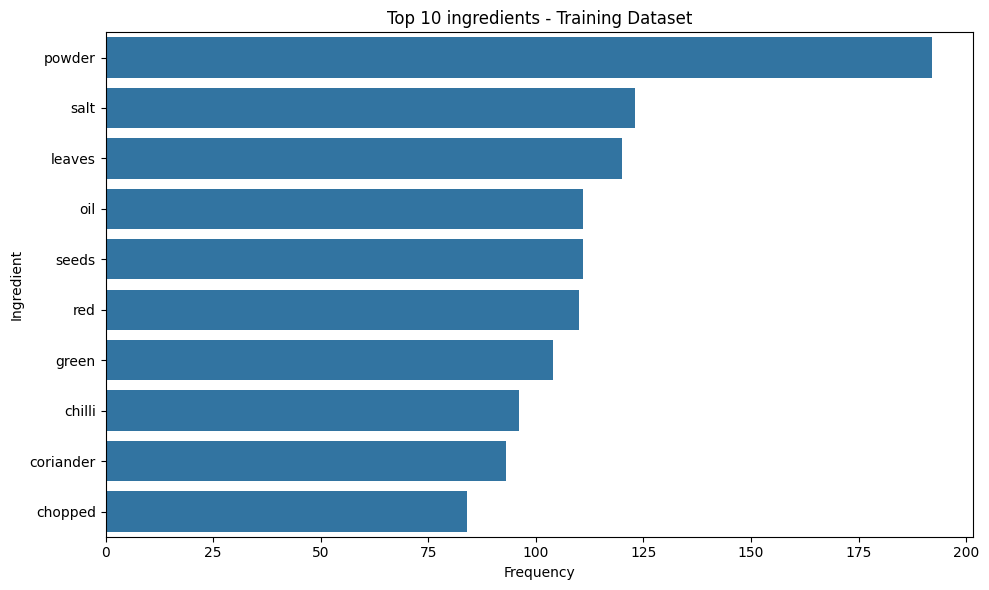

In [107]:
# plot the top frequent ingredients in training data
plot_top_items(top_ingredients, "ingredient", dataset_name)


In [70]:
from collections import Counter

unit_counter = Counter()

for tokens, labels in zip(train_df["input_tokens"], train_df["pos_tokens"]):
    for token, label in zip(tokens, labels):
        if label == "unit":
            unit_counter[token] += 1

top_units = unit_counter.most_common(10)

print(top_units)

[('teaspoon', 162), ('cup', 136), ('tablespoon', 99), ('grams', 63), ('tablespoons', 61), ('inch', 52), ('cups', 50), ('sprig', 41), ('cloves', 39), ('teaspoons', 39)]


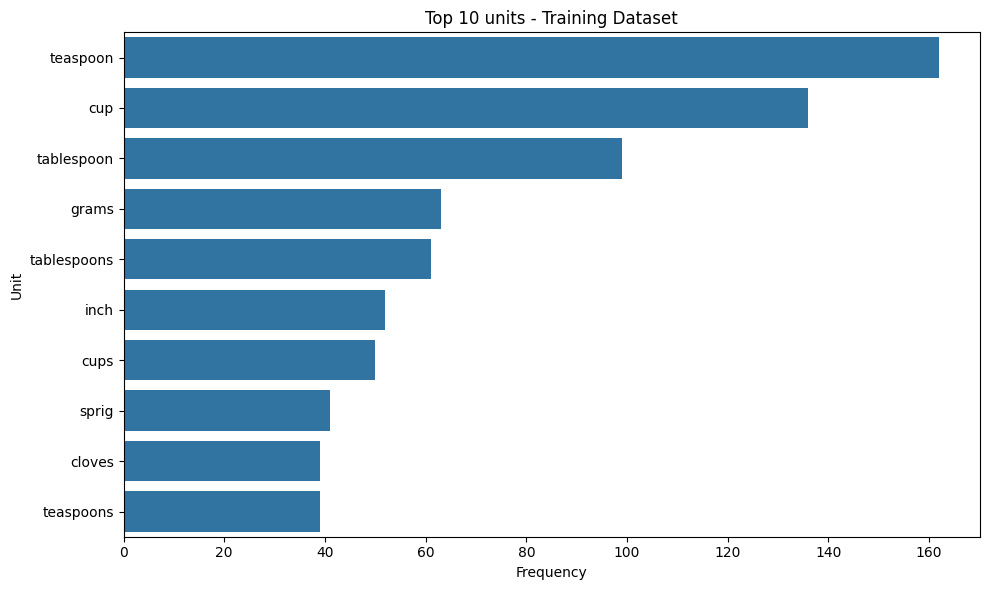

In [71]:
# plot the top frequent units in training data
plot_top_items(top_units, "unit", dataset_name)


## **5** Exploratory Recipe Data Analysis on Validation Dataset (Optional)<font color = red> [0 marks]</font> <br>

#### **5.1** *Execute EDA on Validation Dataset with insights (Optional)* <font color = red> [0 marks]</font> <br>
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.



In [108]:
# initialise the dataset_name
dataset_name = "Validation"


In [109]:
# use extract and validate tokens, categorise tokens, get top frequent items for ingredient list and unit list on validation dataframe
validation_input_tokens, validation_pos_tags = extract_and_validate_tokens(
    val_df, dataset_name
)

val_ingredient_list, val_unit_list, val_quantity_list = categorize_tokens(
    validation_input_tokens, validation_pos_tags
)

val_top_ingredients = get_top_frequent_items(
    val_ingredient_list, "ingredient", dataset_name
)
val_top_units = get_top_frequent_items(
    val_unit_list, "unit", dataset_name
)


Validation input token count: 2876
Validation POS/NER label count: 2876
Lengths match: True
First 10 Validation input tokens: ['1', 'cup', 'Ada', '2', 'liter', 'Milk', '3/4', 'Sugar', 'tablespoon', 'Ghee']
First 10 Validation labels: ['quantity', 'unit', 'ingredient', 'quantity', 'unit', 'ingredient', 'quantity', 'ingredient', 'unit', 'ingredient']
Top 10 ingredients in Validation dataset:


,ingredient,frequency
0,powder,79
1,salt,57
2,oil,54
3,red,52
4,leaves,52
5,seeds,50
6,chilli,41
7,green,37
8,garlic,36
9,coriander,33


Top 10 units in Validation dataset:


,unit,frequency
0,teaspoon,59
1,cup,57
2,tablespoon,32
3,tablespoons,32
4,cups,24
5,sprig,22
6,inch,20
7,grams,19
8,teaspoons,18
9,cloves,16


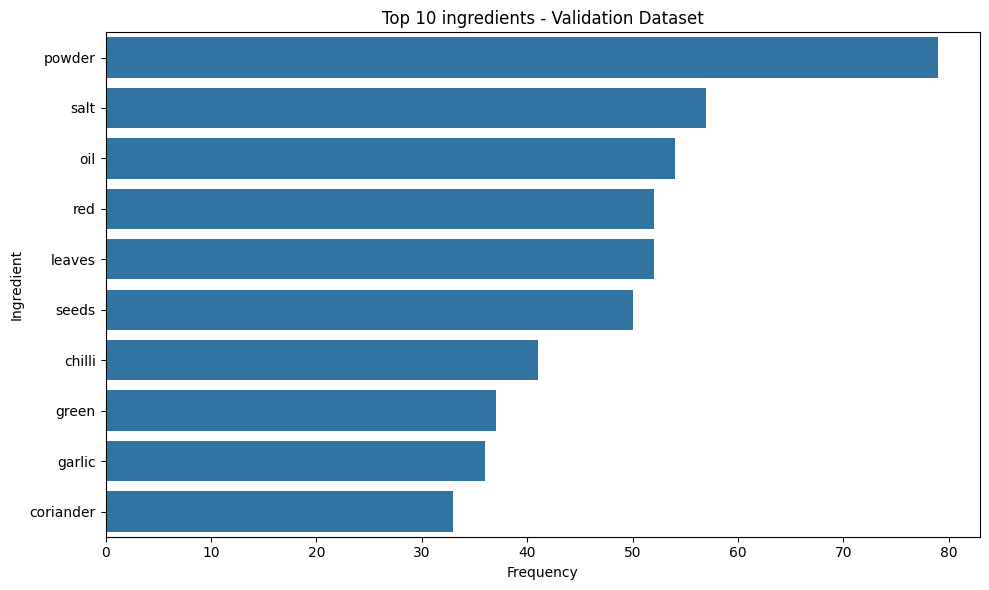

In [56]:
# plot the top frequent ingredients in validation data
plot_top_items(val_top_ingredients, "ingredient", dataset_name)


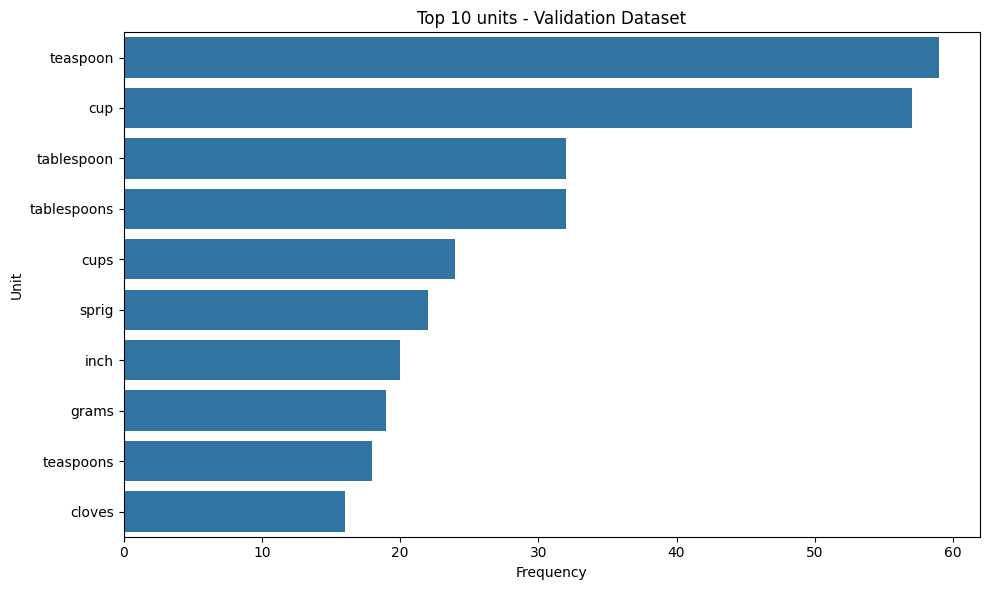

In [57]:
# plot the top frequent units in training data
plot_top_items(val_top_units, "unit", dataset_name)


## **6** Feature Extraction For CRF Model <font color = red>[30 marks]</font> <br>

### **6.1** *Define a feature functions to take each token from recipe* <font color = red>[10 marks]</font>

Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals** <font color = red>[3 marks]</font> <br>

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [113]:
import spacy

print("spaCy version:", spacy.__version__)

spaCy version: 3.8.16


In [114]:
import sys
!{sys.executable} -m pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 2.1 MB/s eta 0:00:06
     ---- ----------------------------------- 1.6/12.8 MB 3.2 MB/s eta 0:00:04
     ----- ---------------------------------- 1.8/12.8 MB 2.7 MB/s eta 0:00:05
     --------- ------------------------------ 2.9/12.8 MB 3.2 MB/s eta 0:00:04
     ------------- -------------------------- 4.2/12.8 MB 3.8 MB/s eta 0:00:03
     ------------------ --------------------- 5.8/12.8 MB 4.4 MB/s eta 0:00:02
     ---------------------- ----------------- 7.1/12.8 MB 4.6 MB/s eta 0:00:02
     ----------------------- ---------------- 7.6/12.8 MB 4.6 MB/s eta 0:00:02
     ------------------------- -------------- 8.1/12.8 MB 4.2 MB/s eta 0:00:02
     -------------------------- ------------- 8.4/12.8 MB 3.9 MB/s eta 0:00:02
     --------------------------- ------------ 8.7/12.8 MB 3.7 MB/s


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [115]:
# define unit and quantity keywords along with quantity pattern
import re
unit_keywords = {
    "cup", "cups", "teaspoon", "teaspoons", "tsp", "tablespoon", "tablespoons",
    "tbsp", "gram", "grams", "kg", "kilogram", "kilograms", "ml", "liter",
    "liters", "litre", "litres", "inch", "inches", "sprig", "sprigs",
    "clove", "cloves", "pinch", "pinches", "bunch", "bunches", "handful",
    "piece", "pieces", "slice", "slices", "small", "large", "cm", "mm",
    "oz", "ounce", "ounces", "pound", "pounds", "lb", "lbs", "drop", "drops",
    "fistful", "stalk", "stalks", "can", "cans"
}

quantity_keywords = {
    "half", "quarter", "third", "three-quarter", "three-fourth", "one-half",
    "one-third", "one-fourth", "a", "an", "few", "several", "handful"
}

quantity_pattern = re.compile(
    r"^(?:\d+(?:-\d+)?(?:/\d+)?|\d*\.\d+|\d+/\d+|\d+-\d+/\d+)$"
)


In [116]:
import spacy

print("spaCy version:", spacy.__version__)

nlp = spacy.load("en_core_web_sm")

print("Model loaded successfully!")

spaCy version: 3.8.16
Model loaded successfully!


In [117]:
# load spaCy model
try:
    nlp = spacy.load("en_core_web_sm")
    print("Loaded spaCy model: en_core_web_sm")
except OSError:
    print("en_core_web_sm is not installed. Using a blank English pipeline; install/download en_core_web_sm before the final CRF run.")
    nlp = spacy.blank("en")


Loaded spaCy model: en_core_web_sm


##### **6.1.2** **Define feature functions for CRF** <font color = red>[7 marks]</font> <br>

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens

While building ***features*** dictionary, include
- ***Core Features*** - The core features of a token should capture its lexical
and grammatical properties. Include attributes like the raw token, its lemma, part-of-speech tag, dependency relation, and shape, as well as indicators for whether it's a stop word, digit, or punctuation. The details of the features are given below:

    - `bias` - Constant feature with a fixed value of 1.0 to aid model learning.
    - `token` - The lowercase form of the current token.
    - `lemma` - The lowercase lemma (base form) of the token.
    - `pos_tag` - Part-of-speech (POS) tag of the token.
    - `tag` - Detailed POS tag of the token.
    - `dep` - Dependency relation of the token in the sentence.
    - `shape` - Shape of the token (e.g., "Xxx" for "Milk").
    - `is_stop` - Boolean indicating if the token is a stopword.
    - `is_digit` - Boolean indicating if the token consists of only digits.
    - `has_digit` - Boolean indicating if the token contains at least one digit.
    - `has_alpha` - Boolean indicating if the token contains at least one alphabetic character.
    - `hyphenated` - Boolean indicating if the token contains a hyphen (-).
    - `slash_present` - Boolean indicating if the token contains a slash (/).
    - `is_title` - Boolean indicating if the token starts with an uppercase letter.
    - `is_upper` - Boolean indicating if the token is fully uppercase.
    - `is_punct` - Boolean indicating if the token is a punctuation mark.

- ***Improved Quantity and Unit Detection*** - Use key-value pairs to mark the presence of quantities and units in the features dictionary. Utilise the unit_keywords, quantity_keywords, and quantity_pattern to identify and flag these elements. The details of the features are given below:

    - `is_quantity` - Boolean indicating if the token matches a quantity pattern or keyword.
    - `is_unit` - Boolean indicating if the token is a known measurement unit.
    - `is_numeric` - Boolean indicating if the token matches a numeric pattern.
    - `is_fraction` - Boolean indicating if the token represents a fraction (e.g., 1/2).
    - `is_decimal` - Boolean indicating if the token represents a decimal number (e.g., 3.14).
    - `preceding_word` - The previous token in the sentence, if available.
    - `following_word` - The next token in the sentence, if available.

- ***Contextual Features*** - Incorporate contextual information by adding features for the preceding and following tokens. Include indicators like BOS and EOS to mark the beginning and end of the sequence, and utilise unit_keywords, quantity_keywords, and quantity_pattern to identify the types of neighboring tokens. The features are given below:

    - `prev_token` - The lowercase form of the previous token.
    - `prev_is_quantity` - Boolean indicating if the previous token is a quantity.
    - `prev_is_digit` - Boolean indicating if the previous token is a digit.
    - `BOS` - Boolean indicating if the token is at the beginning of the sentence.
    - `next_token` - The lowercase form of the next token.
    - `next_is_unit` - Boolean indicating if the next token is a unit.
    - `next_is_ingredient` - Boolean indicating if the next token is not a unit or quantity.
    - `EOS` - Boolean indicating if the token is at the end of the sentence.



In [118]:
# define word2features for processing each token in the sentence sent by using index i.
# use your own feature functions
def word2features(sent, i):
    token_text = str(sent[i])

    # Process the complete sentence while preserving the original whitespace tokens.
    doc = spacy.tokens.Doc(nlp.vocab, words=[str(token) for token in sent])
    doc = nlp(doc)
    spacy_token = doc[i]

    lower_token = token_text.lower()

    def is_quantity_token(token):
        value = token.lower()
        return bool(quantity_pattern.match(value)) or value in quantity_keywords

    def is_unit_token(token):
        return token.lower() in unit_keywords

    features = {
        "bias": 1.0,

        # --- Core Features ---
        "token": lower_token,
        "lemma": spacy_token.lemma_.lower() if spacy_token.lemma_ else lower_token,
        "pos_tag": spacy_token.pos_,
        "tag": spacy_token.tag_,
        "dep": spacy_token.dep_,
        "shape": spacy_token.shape_,
        "is_stop": spacy_token.is_stop,
        "is_digit": token_text.isdigit(),
        "has_digit": any(ch.isdigit() for ch in token_text),
        "has_alpha": any(ch.isalpha() for ch in token_text),
        "hyphenated": "-" in token_text,
        "slash_present": "/" in token_text,
        "is_title": token_text.istitle(),
        "is_upper": token_text.isupper(),
        "is_punct": spacy_token.is_punct,

        # --- Improved Quantity & Unit Detection ---
        "is_quantity": is_quantity_token(token_text),
        "is_unit": is_unit_token(token_text),
        "is_numeric": bool(re.fullmatch(r"\d+(?:\.\d+)?", token_text)),
        "is_fraction": bool(re.fullmatch(r"\d+/\d+", token_text)) or "/" in token_text,
        "is_decimal": bool(re.fullmatch(r"\d*\.\d+", token_text)),

        "preceding_word": sent[i - 1].lower() if i > 0 else "",
        "following_word": sent[i + 1].lower() if i < len(sent) - 1 else "",
    }

    # --- Contextual Features ---
    if i > 0:
        prev_token = str(sent[i - 1])
        features.update({
            "prev_token": prev_token.lower(),
            "prev_is_quantity": is_quantity_token(prev_token),
            "prev_is_digit": prev_token.isdigit(),
            "BOS": False,
        })
    else:
        features.update({
            "prev_token": "__BOS__",
            "prev_is_quantity": False,
            "prev_is_digit": False,
            "BOS": True,
        })

    if i < len(sent) - 1:
        next_token = str(sent[i + 1])
        features.update({
            "next_token": next_token.lower(),
            "next_is_unit": is_unit_token(next_token),
            "next_is_ingredient": not is_unit_token(next_token) and not is_quantity_token(next_token),
            "EOS": False,
        })
    else:
        features.update({
            "next_token": "__EOS__",
            "next_is_unit": False,
            "next_is_ingredient": False,
            "EOS": True,
        })

    return features


### **6.2** *Preparation of Recipe level features* <font color = red>[2 marks]</font>


##### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe** <font color = red>[2 marks]</font> <br>

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [119]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features
def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]


In [120]:
import json
import pandas as pd

file_path = r"D:\Downloads\Starter+Notebook+++Data (2)\ingredient_and_quantity.json"

with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (285, 2)
                                               input  \
0  6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 ...   
1  2-1/2 cups rice cooked 3 tomatoes teaspoons BC...   
2  1-1/2 cups Rice Vermicelli Noodles Thin 1 Onio...   
3  500 grams Chicken 2 Onion chopped 1 Tomato 4 G...   
4  1 tablespoon chana dal white urad 2 red chilli...   

                                                 pos  
0  quantity ingredient ingredient ingredient ingr...  
1  quantity unit ingredient ingredient quantity i...  
2  quantity unit ingredient ingredient ingredient...  
3  quantity unit ingredient quantity ingredient i...  
4  quantity unit ingredient ingredient ingredient...  


In [121]:
print(df.columns.tolist())

['input', 'pos']


### **6.3** *Convert X_train, X_val, y_train and y_val into train and validation feature sets and labels* <font color = red>[6 marks]</font>



In [122]:
df["input_tokens"] = df["input"].apply(lambda x: x.split())
df["pos_tokens"] = df["pos"].apply(lambda x: x.split())

In [123]:
df = df[
    df["input_tokens"].apply(len) == df["pos_tokens"].apply(len)
].reset_index(drop=True)

print("Valid recipes:", len(df))

Valid recipes: 280


In [124]:
X_train = train_df["input_tokens"].tolist()
y_train = train_df["pos_tokens"].tolist()

X_val = val_df["input_tokens"].tolist()
y_val = val_df["pos_tokens"].tolist()

print("X_train:", len(X_train))
print("y_train:", len(y_train))
print("X_val:", len(X_val))
print("y_val:", len(y_val))

X_train: 196
y_train: 196
X_val: 84
y_val: 84


In [125]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

print("Training recipes:", len(train_df))
print("Validation recipes:", len(val_df))

Training recipes: 196
Validation recipes: 84


##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val** <font color = red>[2 marks]</font> <br>

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

In [126]:
# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features
X_train_features = [sent2features(sentence) for sentence in X_train]
X_val_features = [sent2features(sentence) for sentence in X_val]


##### **6.3.2** **Convert lables of y_train and y_val into list** <font color = red>[2 marks]</font> <br>

Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [127]:
# Convert labels into list as y_train_labels and y_val_labels
y_train_labels = [list(labels) for labels in y_train]
y_val_labels = [list(labels) for labels in y_val]


##### **6.3.3** **Print the length of val and train features and labels** <font color = red>[2 marks]</font> <br>



In [128]:
# print the length of train features and labels
print("Training feature sequences:", len(X_train_features))
print("Training label sequences:", len(y_train_labels))


Training feature sequences: 196
Training label sequences: 196


In [129]:
# print the length of validation features and labels
print("Validation feature sequences:", len(X_val_features))
print("Validation label sequences:", len(y_val_labels))


Validation feature sequences: 84
Validation label sequences: 84


### **6.4** *Applying weights to feature sets* <font color = red>[12 marks]</font> <br>




##### **6.4.1** **Flatten the labels of y_train** <font color = red>[2 marks]</font> <br>

Create ***y_train_flat*** to flatten the structure of nested y_train

In [130]:
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in sublist]

In [131]:
y_train_labels = y_train

In [132]:
# Flatten labels in y_train
y_train_flat = flatten_list(y_train_labels)


##### **6.4.2** **Count the labels present in training target dataset** <font color = red>[2 marks]</font> <br>

Create ***label_counts*** to count the frequencies of labels present in y_train_flat and retrieve the total samples by using the values of label_counts as ***total_samples***

In [133]:
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts
from collections import Counter
label_counts = Counter(y_train_flat)
total_samples = sum(label_counts.values())

print("Label counts:", label_counts)
print("Total labelled tokens:", total_samples)


Label counts: Counter({'ingredient': 5323, 'quantity': 980, 'unit': 811})
Total labelled tokens: 7114


##### **6.4.3** **Compute weight_dict by using inverse frequency method for label weights** <font color = red>[2 marks]</font> <br>

- Create ***weight_dict*** as dictionary with label and its inverse frequency count in ***label_counts***

- Penalise ingredient label in the dictionary

In [134]:
# Compute class weights (inverse frequency method) by considering total_samples and label_counts
weight_dict = {
    label: total_samples / (len(label_counts) * count)
    for label, count in label_counts.items()
}
print("Initial inverse-frequency weights:", weight_dict)


Initial inverse-frequency weights: {'quantity': 2.419727891156463, 'unit': 2.923962186600904, 'ingredient': 0.44548813325818776}


In [135]:
# penalise ingredient label
# Ingredient is the majority class in this dataset, so its inverse-frequency weight
# is increased modestly to encourage the model to pay attention to ingredient boundaries.
if "ingredient" in weight_dict:
    weight_dict["ingredient"] *= 1.25

print("Final class weights:", weight_dict)


Final class weights: {'quantity': 2.419727891156463, 'unit': 2.923962186600904, 'ingredient': 0.5568601665727347}


##### **6.4.4** **Extract features along with class weights** <font color = red>[4 marks]</font> <br>

Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights





In [136]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)
def extract_features_with_class_weights(X, y, weight_dict):
    weighted_features = []

    for sentence_features, sentence_labels in zip(X, y):
        sentence_weighted_features = []

        for token_features, label in zip(sentence_features, sentence_labels):
            feature_copy = token_features.copy()

            # Apply an observable token-level class weight rather than the gold label.
            # This avoids target leakage while still incorporating the manually
            # calculated class weights into the feature representation.
            if feature_copy.get("is_quantity", False):
                token_class = "quantity"
            elif feature_copy.get("is_unit", False):
                token_class = "unit"
            else:
                token_class = "ingredient"

            feature_copy["class_weight"] = round(
                weight_dict.get(token_class, 1.0), 6
            )
            sentence_weighted_features.append(feature_copy)

        weighted_features.append(sentence_weighted_features)

    return weighted_features


##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets** <font color = red>[2 marks]</font> <br>

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [137]:
# Apply manually computed class weights
X_train_weighted_features = extract_features_with_class_weights(
    X_train_features, y_train_labels, weight_dict
)

# The same observable-token weighting logic is used for validation.
X_val_weighted_features = extract_features_with_class_weights(
    X_val_features, y_val_labels, weight_dict
)

print("Weighted training sequences:", len(X_train_weighted_features))
print("Weighted validation sequences:", len(X_val_weighted_features))


Weighted training sequences: 196
Weighted validation sequences: 84


## **7** Model Building and Training <font color = red>[10 marks]</font> <br>

### **7.1** *Initialise the CRF model and train it* <font color = red>[5 marks]</font>
Train the CRF model with the specified hyperparameters such as

### CRF Model Hyperparameters Explanation

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF



In [138]:
# initialise CRF model with the specified hyperparameters and use weight_dict
import sklearn_crfsuite
crf_model = sklearn_crfsuite.CRF(
    algorithm="lbfgs",
    c1=0.5,
    c2=1.0,
    max_iterations=100,
    all_possible_transitions=True
)

# train the CRF model with the weighted training data
crf_model.fit(X_train_weighted_features, y_train_labels)


CRF(algorithm='lbfgs', all_possible_transitions=True, c1=0.5, c2=1.0,
    max_iterations=100)

### **7.2** *Evaluation of Training Dataset using CRF model* <font color = red>[4 marks]</font>
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [139]:
# evaluate on the training dataset
y_pred_train = crf_model.predict(X_train_weighted_features)


In [140]:
# specify the flat classification report by using training data for evaluation
from sklearn_crfsuite.metrics import flat_classification_report
print(flat_classification_report(
    y_train_labels,
    y_pred_train,
    labels=["quantity", "unit", "ingredient"]
))


              precision    recall  f1-score   support

    quantity       1.00      0.99      0.99       980
        unit       0.98      0.97      0.97       811
  ingredient       0.99      1.00      0.99      5323

    accuracy                           0.99      7114
   macro avg       0.99      0.98      0.99      7114
weighted avg       0.99      0.99      0.99      7114



,quantity,unit,ingredient
quantity,966,0,14
unit,0,785,26
ingredient,4,19,5300


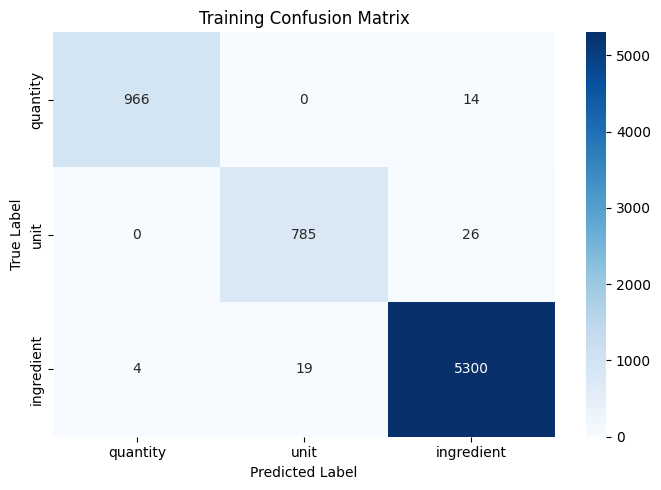

In [141]:
# create a confusion matrix on training datset
from sklearn.metrics import confusion_matrix
train_true_flat = flatten_list(y_train_labels)
train_pred_flat = flatten_list(y_pred_train)

train_cm = confusion_matrix(
    train_true_flat,
    train_pred_flat,
    labels=["quantity", "unit", "ingredient"]
)

cm_df = pd.DataFrame(
    train_cm,
    index=["quantity", "unit", "ingredient"],
    columns=["quantity", "unit", "ingredient"]
)
display(cm_df)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Training Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


### **7.3** *Save the CRF model* <font color = red>[1 marks]</font>
Save the CRF model

In [142]:
# dump the model using joblib as crf_model.pkl
joblib.dump(crf_model, "crf_model.pkl")
print("Model saved as crf_model.pkl")


Model saved as crf_model.pkl


## **8** Prediction and Model Evaluation <font color = red>[3 marks]</font> <br>

### **8.1** *Predict and Evaluate the CRF model on validation set* <font color = red>[3 marks]</font>
Evaluate the metrics for CRF model by using flat classification report and confusion matrix




In [143]:
# predict the crf model on validation dataset
y_pred_val = crf_model.predict(X_val_weighted_features)


In [144]:
# specify flat classification report
print(flat_classification_report(
    y_val_labels,
    y_pred_val,
    labels=["quantity", "unit", "ingredient"]
))


              precision    recall  f1-score   support

    quantity       0.99      0.99      0.99       411
        unit       0.95      0.92      0.93       358
  ingredient       0.98      0.99      0.99      2107

    accuracy                           0.98      2876
   macro avg       0.98      0.97      0.97      2876
weighted avg       0.98      0.98      0.98      2876



,quantity,unit,ingredient
quantity,406,2,3
unit,1,328,29
ingredient,4,14,2089


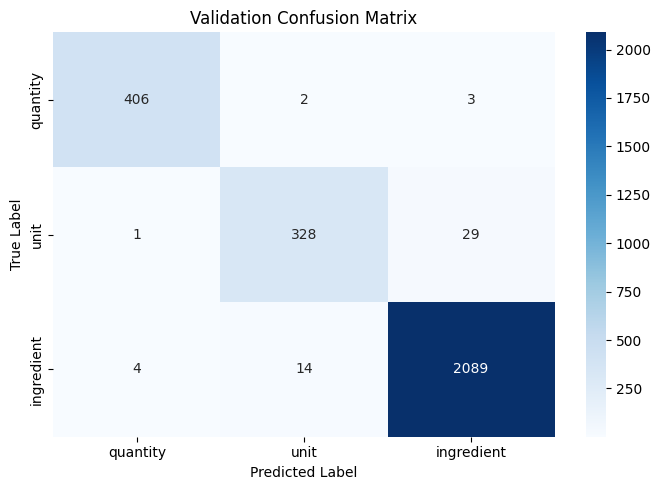

In [145]:
# create a confusion matrix on validation dataset
val_true_flat = flatten_list(y_val_labels)
val_pred_flat = flatten_list(y_pred_val)

val_cm = confusion_matrix(
    val_true_flat,
    val_pred_flat,
    labels=["quantity", "unit", "ingredient"]
)

val_cm_df = pd.DataFrame(
    val_cm,
    index=["quantity", "unit", "ingredient"],
    columns=["quantity", "unit", "ingredient"]
)
display(val_cm_df)

plt.figure(figsize=(7, 5))
sns.heatmap(val_cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


## **9** Error Analysis on Validation Data <font color = red>[10 marks]</font> <br>
Investigate misclassified samples in validation dataset and provide the insights


### **9.1** *Investigate misclassified samples in validation dataset* <font color = red>[8 marks]</font>



##### **9.1.1** Flatten the labels of validation data and initialise error data <font color = red>[2 marks]</font> <br>



Flatten the true and predicted labels and initialise the error data as ***error_data***

In [146]:
# flatten Labels and Initialise Error Data
error_data = []
y_val_flat = flatten_list(y_val_labels)
y_pred_val_flat = flatten_list(y_pred_val)


##### **9.1.2** Iterate the validation data and collect Error Information<font color = red> [2 marks]</font> <br>



Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [147]:
# iterate and collect Error Information
for recipe_idx, (tokens, true_labels, pred_labels) in enumerate(
    zip(X_val, y_val_labels, y_pred_val)
):
    for token_idx, (token, true_label, pred_label) in enumerate(
        zip(tokens, true_labels, pred_labels)
    ):
        if true_label != pred_label:
            previous_token = tokens[token_idx - 1] if token_idx > 0 else "<START>"
            next_token = tokens[token_idx + 1] if token_idx < len(tokens) - 1 else "<END>"

            error_data.append({
                "recipe_index": recipe_idx,
                "token": token,
                "previous_token": previous_token,
                "next_token": next_token,
                "true_label": true_label,
                "predicted_label": pred_label,
                "class_weight": weight_dict.get(true_label, 1.0),
                "context": " ".join(tokens[max(0, token_idx-2):min(len(tokens), token_idx+3)])
            })


##### **9.1.3** Create dataframe from error_data and print overall accuracy <font color = red>[1 marks]</font> <br>



Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

In [148]:
# Create DataFrame and Print Overall Accuracy
error_df = pd.DataFrame(error_data)

overall_accuracy = sum(
    true_label == pred_label
    for true_seq, pred_seq in zip(y_val_labels, y_pred_val)
    for true_label, pred_label in zip(true_seq, pred_seq)
) / sum(len(seq) for seq in y_val_labels)

print(f"Overall validation token accuracy: {overall_accuracy:.4f}")
print("Number of misclassified tokens:", len(error_df))
display(error_df.head(20))


Overall validation token accuracy: 0.9816
Number of misclassified tokens: 53


,recipe_index,token,previous_token,next_token,true_label,predicted_label,class_weight,context
0,2,few,Leaves,<END>,ingredient,quantity,0.556860,Tamarind Leaves few
1,5,cloves,3,garlic,ingredient,unit,0.556860,chillies 3 cloves garlic big
2,5,Spoon,big,oil,unit,ingredient,2.923962,garlic big Spoon oil teaspoon
3,6,cloves,seeds,garlic,unit,ingredient,2.923962,cumin seeds cloves garlic grated
4,6,pieces,small,1/4,ingredient,unit,0.556860,into small pieces 1/4 peas
5,13,is,Pur,2,quantity,ingredient,2.419728,Pani Pur is 2 Potato
6,15,few,Leaves,<END>,ingredient,quantity,0.556860,Salt Leaves few
7,16,cloves,oregano,Garlic,unit,ingredient,2.923962,Dried oregano cloves Garlic minced
8,16,to,sugar,tablespoons,quantity,ingredient,2.419728,Cane sugar to tablespoons Extra
9,19,for,Oil,kneading,quantity,ingredient,2.419728,Sunflower Oil for kneading 4


##### **9.1.4** Analyse errors by label type<font color = red> [3 marks]</font> <br>
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [149]:
# Analyse errors found in the validation data by each label
# and display their class weights along with accuracy
# and display the error dataframe with token, previous token, next token, true label, predicted label and context
error_summary = []

for label in sorted(set(y_val_flat)):
    total = sum(1 for true_label in y_val_flat if true_label == label)
    correct = sum(
        1
        for true_label, pred_label in zip(y_val_flat, y_pred_val_flat)
        if true_label == label and pred_label == label
    )
    accuracy = correct / total if total else 0

    error_summary.append({
        "label": label,
        "class_weight": weight_dict.get(label, 1.0),
        "support": total,
        "correct": correct,
        "label_accuracy": accuracy,
        "errors": total - correct
    })

error_summary_df = pd.DataFrame(error_summary)
display(error_summary_df)

print("Misclassified validation samples:")
display(error_df[
    ["token", "previous_token", "next_token", "true_label", "predicted_label", "context"]
].head(50))


,label,class_weight,support,correct,label_accuracy,errors
0,ingredient,0.556860,2107,2089,0.991457,18
1,quantity,2.419728,411,406,0.987835,5
2,unit,2.923962,358,328,0.916201,30


Misclassified validation samples:


,token,previous_token,next_token,true_label,predicted_label,context
0,few,Leaves,<END>,ingredient,quantity,Tamarind Leaves few
1,cloves,3,garlic,ingredient,unit,chillies 3 cloves garlic big
2,Spoon,big,oil,unit,ingredient,garlic big Spoon oil teaspoon
3,cloves,seeds,garlic,unit,ingredient,cumin seeds cloves garlic grated
4,pieces,small,1/4,ingredient,unit,into small pieces 1/4 peas
5,is,Pur,2,quantity,ingredient,Pani Pur is 2 Potato
6,few,Leaves,<END>,ingredient,quantity,Salt Leaves few
7,cloves,oregano,Garlic,unit,ingredient,Dried oregano cloves Garlic minced
8,to,sugar,tablespoons,quantity,ingredient,Cane sugar to tablespoons Extra
9,for,Oil,kneading,quantity,ingredient,Sunflower Oil for kneading 4


### **9.2** *Provide insights from the validation dataset* <font color = red>[2 marks]</font>




The validation results should be interpreted using the token-level classification report, confusion matrix and error-analysis table above. Particular attention should be paid to confusion between **ingredient** tokens and tokens that resemble measurement/context words, as well as quantity/unit patterns that occur in varied formats. The error table provides surrounding-token context to identify recurring failure patterns and opportunities for improving the feature set.


## **10** Conclusion (Optional) <font color = red>[0 marks]</font> <br>

Write your findings and conclusion.